# Notebook 02 — Análises Exploratórias e Cruzamento CESOP × TSE

**Objetivo:** explorar visualmente as bases tratadas no notebook 01 e iniciar o cruzamento entre a percepção declarada (CESOP) e o comportamento eleitoral observado (TSE 2022).

**Bases consumidas:**
- `cesop_clean.parquet` — 2.000 respondentes com perguntas recodificadas
- `tse_clean.parquet` — linhas-detalhe (município × perfil) com taxas
- `tse_uf.parquet` — agregado por UF
- `tse_perfil.parquet` — agregado por perfil demográfico nacional

**Estrutura:**
1. Setup
2. Perfil sociodemográfico CESOP
3. Lembrança do voto em 2022
4. Prioridades políticas
5. Combate às fake news
6. Vontade de participar da política local
7. Panorama eleitoral TSE 2022
8. **Cruzamento CESOP × TSE**
9. Síntese


## 0. Setup


In [29]:
# Imports e configuração estética.
# A configuração centralizada do seaborn/matplotlib evita repetir parâmetros nos gráficos.
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# Paletas reutilizadas ao longo do notebook (consistência visual).
PALETA_REGIAO = {
    "Norte": "#1b9e77",
    "Nordeste": "#d95f02",
    "Sudeste": "#7570b3",
    "Sul": "#e7298a",
    "Centro-Oeste": "#66a61e",
}
CORES_VONTADE = ["#1b9e77", "#fdae61", "#d7191c"]  # muita, alguma, nenhuma
COR_PRINCIPAL = "#3b5998"
COR_SECUNDARIA = "#e8a09a"


In [30]:
# Paths e leitura das bases tratadas.
PROJECT_ROOT = Path("..").resolve()
PATH_PROCESSED = PROJECT_ROOT / "data" / "processed"
PATH_FIGURAS = PROJECT_ROOT / "reports" / "imagens"
PATH_FIGURAS.mkdir(parents=True, exist_ok=True)

df_cesop = pd.read_parquet(PATH_PROCESSED / "cesop_clean.parquet")
df_tse = pd.read_parquet(PATH_PROCESSED / "tse_clean.parquet")
df_tse_uf = pd.read_parquet(PATH_PROCESSED / "tse_uf.parquet")
df_tse_perfil = pd.read_parquet(PATH_PROCESSED / "tse_perfil.parquet")

print(f"CESOP       : {df_cesop.shape}")
print(f"TSE detalhe : {df_tse.shape}")
print(f"TSE por UF  : {df_tse_uf.shape}")
print(f"TSE perfil  : {df_tse_perfil.shape}")


CESOP       : (2000, 30)
TSE detalhe : (8785738, 13)
TSE por UF  : (28, 7)
TSE perfil  : (498, 9)


## 1. Perfil sociodemográfico — CESOP

Quem é a amostra de 2.000 respondentes? Os painéis a seguir apresentam, em percentual, a composição da amostra em três dimensões: demográfica, territorial e socioeconômica.

**Perfil demográfico**

A primeira etapa da análise apresenta a composição demográfica da amostra, considerando sexo, faixa etária, escolaridade e raça/cor dos respondentes.

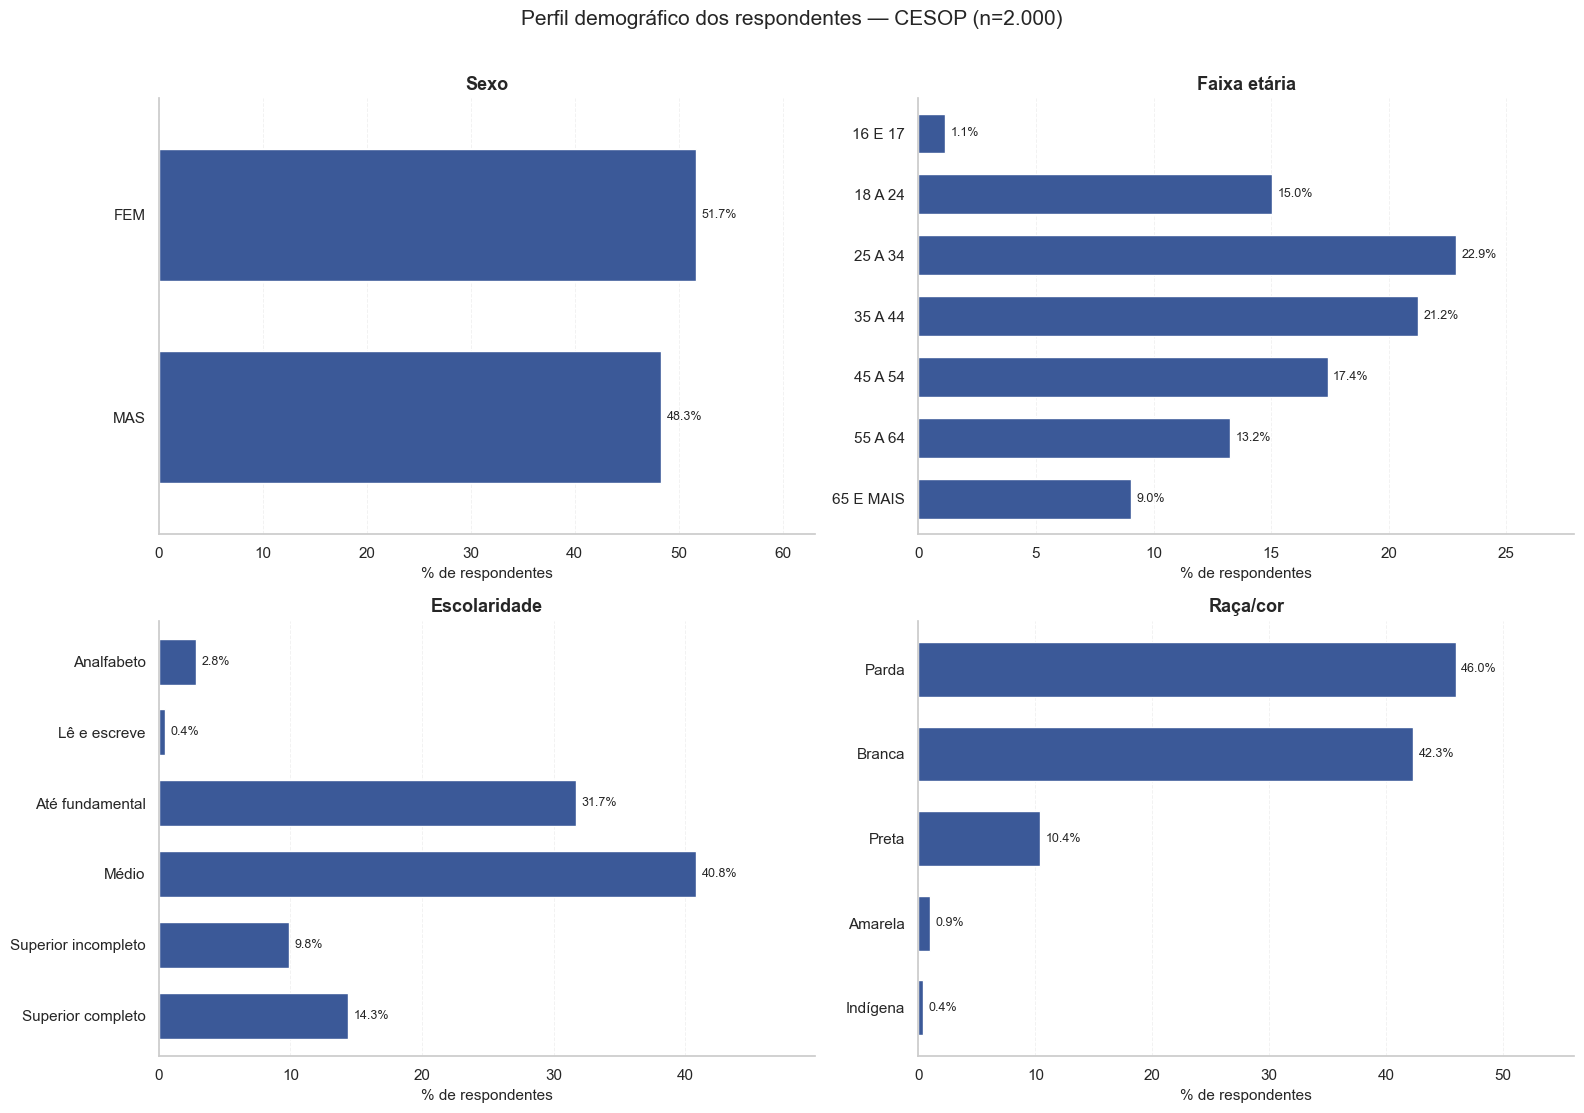

In [31]:
# Helper reutilizado pelas três figuras do perfil sociodemográfico.
# ordered_index define a ordem de cima para baixo; color_map permite cor por categoria.
def _barh_pct(series, ax, color, title, ordered_index=None, color_map=None, xlim=None):
    """Plota barras horizontais em % com rótulos e estilo limpo."""
    pct = series.value_counts(normalize=True) * 100
    if ordered_index is not None:
        pct = pct.reindex(ordered_index).dropna()
        invert = True   # primeira categoria no topo
    else:
        pct = pct.sort_values()
        invert = False  # maior frequência no topo

    cores = [color_map.get(str(c), color) for c in pct.index] if color_map else color

    pct.plot.barh(ax=ax, color=cores, width=0.65, edgecolor="white")
    if invert:
        ax.invert_yaxis()

    ax.set_title(title)
    ax.set_xlabel("% de respondentes")
    ax.set_ylabel("")
    ax.set_xlim(xlim if xlim else (0, min(100, pct.max() * 1.22)))
    ax.grid(axis="y", visible=False)
    ax.grid(axis="x", alpha=0.25, linestyle="--", linewidth=0.7)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%", padding=4, fontsize=9)


# Ordens semânticas explícitas para cada variável.
ORDEM_FX_ID = ["16 E 17", "18 A 24", "25 A 34", "35 A 44", "45 A 54", "55 A 64", "65 E MAIS"]
ORDEM_ESCOL = ["Analfabeto", "Lê e escreve", "Até fundamental", "Médio",
               "Superior incompleto", "Superior completo"]
ORDEM_RENDA = ["Até 1 salário mínimo", "1 a 5 salários mínimos",
               "Acima de 5 salários mínimos", "Acima de 20 salários mínimos"]

# Rosa para feminino, azul para masculino.
CORES_SEXO = {
    "Masculino": COR_PRINCIPAL, "MASCULINO": COR_PRINCIPAL,
    "Feminino": COR_SECUNDARIA, "FEMININO": COR_SECUNDARIA,
}

# ── Figura 1: Perfil demográfico ──────────────────────────────────────────────
fig1, axes1 = plt.subplots(2, 2, figsize=(16, 11))
fig1.suptitle("Perfil demográfico dos respondentes — CESOP (n=2.000)", fontsize=15, y=1.01)

_barh_pct(df_cesop["SEXO"], axes1[0, 0], COR_PRINCIPAL, "Sexo", color_map=CORES_SEXO)
_barh_pct(df_cesop["FX_ID"], axes1[0, 1], COR_PRINCIPAL, "Faixa etária",
          ordered_index=ORDEM_FX_ID)
_barh_pct(df_cesop["ESCOL_GRUPO"], axes1[1, 0], COR_PRINCIPAL, "Escolaridade",
          ordered_index=ORDEM_ESCOL)
_barh_pct(df_cesop["RACA"], axes1[1, 1], COR_PRINCIPAL, "Raça/cor")

plt.tight_layout()
plt.savefig(PATH_FIGURAS / "01a_perfil_demografico.png", dpi=120, bbox_inches="tight")
plt.show()

**Perfil territorial**

Em seguida, observa-se a distribuição regional dos entrevistados, importante para contextualizar possíveis diferenças territoriais nas respostas.

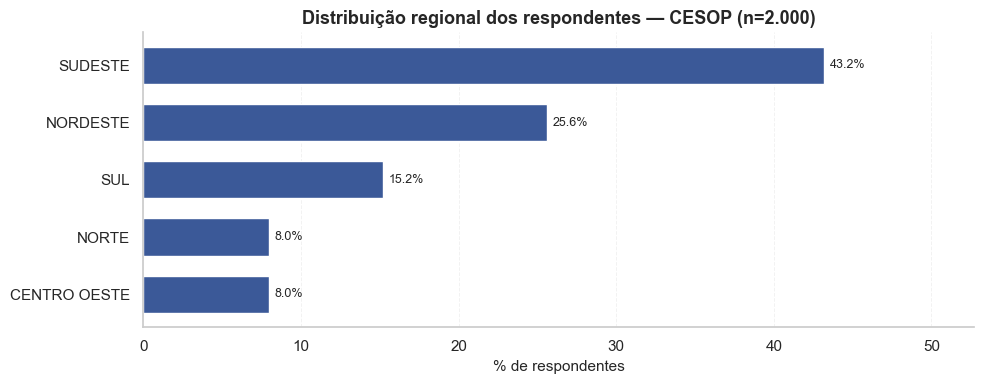

In [32]:
# ── Figura 2: Distribuição regional ───────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(10, 4))

_barh_pct(df_cesop["REGIAO"], ax2, COR_PRINCIPAL,
          "Distribuição regional dos respondentes — CESOP (n=2.000)")

plt.tight_layout()
plt.savefig(PATH_FIGURAS / "01b_perfil_territorial.png", dpi=120, bbox_inches="tight")
plt.show()

**Perfil socioeconômico**

Por fim, as variáveis de renda pessoal e familiar permitem caracterizar a condição econômica individual e domiciliar dos respondentes.

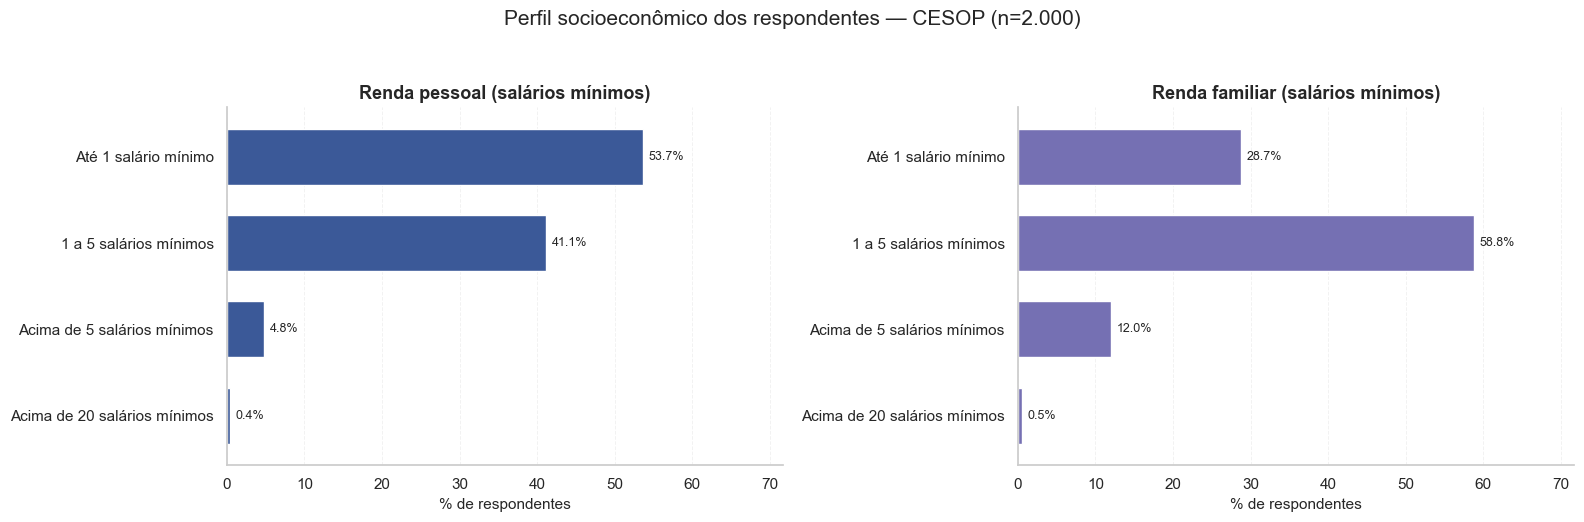

In [33]:
# ── Figura 3: Perfil socioeconômico ───────────────────────────────────────────
# Escala X compartilhada entre renda pessoal e familiar para comparação justa.
max_x_renda = max(
    (df_cesop["RENDA_PESSOAL"].value_counts(normalize=True) * 100).max(),
    (df_cesop["RENDA_FAMILIAR"].value_counts(normalize=True) * 100).max(),
)
xlim_renda = (0, min(100, max_x_renda * 1.22))

fig3, axes3 = plt.subplots(1, 2, figsize=(16, 5))
fig3.suptitle("Perfil socioeconômico dos respondentes — CESOP (n=2.000)", fontsize=15, y=1.04)

_barh_pct(df_cesop["RENDA_PESSOAL"], axes3[0], COR_PRINCIPAL,
          "Renda pessoal (salários mínimos)", ordered_index=ORDEM_RENDA, xlim=xlim_renda)
_barh_pct(df_cesop["RENDA_FAMILIAR"], axes3[1], "#7570b3",
          "Renda familiar (salários mínimos)", ordered_index=ORDEM_RENDA, xlim=xlim_renda)

plt.tight_layout()
plt.savefig(PATH_FIGURAS / "01c_perfil_socioeconomico.png", dpi=120, bbox_inches="tight")
plt.show()

## 2. Lembrança do voto em 2022

Comparamos quanto os respondentes se lembram do voto para os três cargos perguntados (deputado estadual, federal e senador), e como a lembrança varia por escolaridade e idade.


In [ ]:
# === Constantes e helpers compartilhados pelos três gráficos de lembrança de voto ===

COR_SIM       = COR_PRINCIPAL   # azul
COR_NAO       = "#999999"        # cinza médio
COR_NAO_VOTOU = "#f4a261"        # laranja suave

PALETA_LEMBRANCA   = {"Sim": COR_SIM, "Não": COR_NAO, "Não votou": COR_NAO_VOTOU}
CORES_TEXTO_LEMB   = {"Sim": "white", "Não": "white", "Não votou": "#333333"}
ORDEM_LEMBRANCA    = ["Sim", "Não", "Não votou"]

ORDEM_CARGOS_LEMB = ["Deputado(a) estadual", "Deputado(a) federal", "Senador(a)"]
ORDEM_FX_LEMB     = ["16 E 17", "18 A 24", "25 A 34", "35 A 44",
                      "45 A 54", "55 A 64", "65 E MAIS"]
ORDEM_ESCOL_LEMB  = ["Analfabeto", "Lê e escreve", "Até fundamental", "Ensino médio",
                      "Superior incompleto", "Superior completo"]
LIMIAR_ROTULO_LEMB = 5.0  # segmentos < 5% não recebem rótulo


def _cols_lemb(df):
    """Reordena colunas: Sim → Não → Não votou → extras. Retorna df e lista de colunas."""
    fixas  = [c for c in ORDEM_LEMBRANCA if c in df.columns]
    extras = [c for c in df.columns if c not in ORDEM_LEMBRANCA]
    cols   = fixas + extras
    return df[cols], cols


def _rotulos_empilhados(ax, colunas, fmt="%.0f%%", limiar=LIMIAR_ROTULO_LEMB):
    """Rótulos de % no centro de cada segmento; omite segmentos abaixo do limiar."""
    for i, container in enumerate(ax.containers):
        cat = colunas[i]
        cor_txt = CORES_TEXTO_LEMB.get(str(cat), "white")
        for bar in container:
            val = bar.get_width()
            if pd.isna(val) or val < limiar:
                continue
            x = bar.get_x() + val / 2
            y = bar.get_y() + bar.get_height() / 2
            ax.text(x, y, fmt % val, ha="center", va="center",
                    fontsize=9, color=cor_txt, fontweight="bold")


def _estilo_lemb(ax, title, xlabel, xlim=(0, 100)):
    """Aplica estilo padrão compartilhado pelos três gráficos."""
    ax.set_title(title, pad=16)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("")
    ax.set_xlim(xlim)
    ax.grid(axis="y", visible=False)
    ax.grid(axis="x", alpha=0.2, linestyle="--", linewidth=0.7)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def _legenda_lemb(ax, colunas):
    """Legenda padronizada abaixo do gráfico, horizontal, sem borda."""
    ax.legend(
        title="Lembra?", loc="upper center", bbox_to_anchor=(0.5, -0.18),
        ncol=len(colunas), frameon=False, fontsize=9,
    )


# === Gráfico 1: Lembrança por cargo ===
cargos_map = {
    "P_01A": "Deputado(a) estadual",
    "P_01B": "Deputado(a) federal",
    "P_01C": "Senador(a)",
}

df_lembranca_raw = pd.DataFrame({
    label: df_cesop[col].value_counts(normalize=True) * 100
    for col, label in cargos_map.items()
}).T.fillna(0)

df_lembranca, colunas_cargo = _cols_lemb(df_lembranca_raw)
df_lembranca = df_lembranca.reindex(
    [c for c in ORDEM_CARGOS_LEMB if c in df_lembranca.index]
)
cores_cargo = [PALETA_LEMBRANCA.get(c, COR_NAO_VOTOU) for c in colunas_cargo]

fig, ax = plt.subplots(figsize=(11, 5))
df_lembranca[colunas_cargo].plot.barh(ax=ax, color=cores_cargo, width=0.5)
ax.invert_yaxis()
_estilo_lemb(ax, "Lembrança do voto em 2022, por cargo", "% de respondentes", xlim=(0, 115))

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=5, fontsize=9)

_legenda_lemb(ax, colunas_cargo)
plt.tight_layout()
fig.subplots_adjust(bottom=0.2)
plt.show()

print("Categorias encontradas:", colunas_cargo)

In [ ]:
# Lembrança × escolaridade — barras empilhadas horizontais 100%.
# n= calculado antes de crosstab para refletir o total de respondentes por grupo.
counts_escol = df_cesop["ESCOL_GRUPO"].value_counts()

ct_escol_raw = pd.crosstab(df_cesop["ESCOL_GRUPO"], df_cesop["P_01A"], normalize="index") * 100
ct_escol, colunas_e = _cols_lemb(ct_escol_raw)
ct_escol = ct_escol.reindex([c for c in ORDEM_ESCOL_LEMB if c in ct_escol.index])

cores_e = [PALETA_LEMBRANCA.get(c, COR_NAO_VOTOU) for c in colunas_e]

labels_y_escol = [
    f"{cat} (n={int(counts_escol.get(cat, 0)):,})"
    for cat in ct_escol.index
]

fig, ax = plt.subplots(figsize=(12, 6))

ct_escol[colunas_e].plot.barh(stacked=True, ax=ax, color=cores_e, width=0.7)

# Define ticks explicitamente antes de invert para garantir correspondência correta.
ax.set_yticks(range(len(ct_escol.index)))
ax.set_yticklabels(labels_y_escol, fontsize=9)
ax.invert_yaxis()

_estilo_lemb(ax, "Lembrança do voto para deputado(a) estadual, por escolaridade",
             "% dentro do grupo")
_rotulos_empilhados(ax, colunas_e)
_legenda_lemb(ax, colunas_e)

plt.tight_layout()
fig.subplots_adjust(bottom=0.18)
plt.show()

In [ ]:
# Lembrança × faixa etária — barras empilhadas horizontais 100%.
counts_fx = df_cesop["FX_ID"].value_counts()

ct_fx_raw = pd.crosstab(df_cesop["FX_ID"], df_cesop["P_01A"], normalize="index") * 100
ct_fx, colunas_fx = _cols_lemb(ct_fx_raw)
ct_fx = ct_fx.reindex([c for c in ORDEM_FX_LEMB if c in ct_fx.index])

cores_fx = [PALETA_LEMBRANCA.get(c, COR_NAO_VOTOU) for c in colunas_fx]

labels_y_fx = [
    f"{cat} (n={int(counts_fx.get(cat, 0)):,})"
    for cat in ct_fx.index
]

fig, ax = plt.subplots(figsize=(12, 6))

ct_fx[colunas_fx].plot.barh(stacked=True, ax=ax, color=cores_fx, width=0.7)

ax.set_yticks(range(len(ct_fx.index)))
ax.set_yticklabels(labels_y_fx, fontsize=9)
ax.invert_yaxis()

_estilo_lemb(ax, "Lembrança do voto para deputado(a) estadual, por faixa etária",
             "% dentro da faixa")
_rotulos_empilhados(ax, colunas_fx)
_legenda_lemb(ax, colunas_fx)

plt.tight_layout()
fig.subplots_adjust(bottom=0.18)
plt.show()

## 3. Prioridades políticas

Pergunta: *Qual destas propostas você acha que deveria ser prioridade?* Os respondentes citam até 3 prioridades em ordem. Analisamos a 1ª escolha, a frequência acumulada nas 3 posições e a distribuição regional.


In [ ]:
# Top 10 prioridades em 1º lugar.
top1 = df_cesop["P_02_1"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(11, 6))
top1.sort_values().plot.barh(ax=ax, color=COR_PRINCIPAL)
ax.set_title("Prioridades políticas — 1ª escolha")
ax.set_xlabel("Respondentes")
ax.set_ylabel("")
for i, v in enumerate(top1.sort_values()):
    ax.text(v + 5, i, str(int(v)), va="center")
plt.tight_layout()
plt.show()


In [ ]:
# Frequência acumulada nas 3 posições — captura prioridades menos óbvias.
# Algumas propostas raramente são citadas em 1º lugar mas aparecem muito em 2º/3º.
cols_p2 = ["P_02_1", "P_02_2", "P_02_3"]
todas_prio = pd.concat([df_cesop[c] for c in cols_p2], ignore_index=True).dropna()
freq_acum = todas_prio.value_counts(normalize=True).head(10) * 100

fig, ax = plt.subplots(figsize=(11, 6))
freq_acum.sort_values().plot.barh(ax=ax, color="#7570b3")
ax.set_title("Prioridades mais citadas — qualquer das 3 posições")
ax.set_xlabel("% das menções")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


In [ ]:
# Heatmap prioridade × região (top 6 prioridades, normalizado por região).
# Cada coluna soma ~100% — facilita ver onde cada prioridade pesa mais.
top_prios = df_cesop["P_02_1"].value_counts().head(6).index
df_h = df_cesop[df_cesop["P_02_1"].isin(top_prios)]
ct_pr = pd.crosstab(df_h["P_02_1"], df_h["REGIAO"], normalize="columns") * 100

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(ct_pr, annot=True, fmt=".0f", cmap="YlOrRd", ax=ax,
            cbar_kws={"label": "% dentro da região"})
ax.set_title("Prioridade em 1º lugar × Região (% dentro da região)")
ax.set_xlabel("Região")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


## 4. Combate às fake news

Pergunta de múltipla escolha (P.03): *Quais opções poderiam contribuir no combate à divulgação de fake news?* Cada respondente pode citar de 1 a 6 medidas. Consolidamos as 6 colunas (P_03_1 a P_03_6) para obter a frequência total de cada medida.


In [ ]:
# Frequência de cada medida mencionada (consolidando as 6 colunas).
cols_p3 = [f"P_03_{i}" for i in range(1, 7)]
todas_medidas = pd.concat([df_cesop[c] for c in cols_p3], ignore_index=True).dropna()
freq_medidas = todas_medidas.value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
freq_medidas.sort_values().plot.barh(ax=ax, color="#d95f02")
ax.set_title("Medidas mais citadas para combater fake news (todas as menções)")
ax.set_xlabel("Número de menções")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


In [ ]:
# Quantas medidas cada respondente cita?
# Distribuição revela o "esforço de resposta": quem deu apenas 1 vs. quem listou várias.
n_medidas = df_cesop[cols_p3].notna().sum(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
n_medidas.value_counts().sort_index().plot.bar(ax=ax, color="#7570b3", width=0.7)
ax.set_title("Quantas medidas cada respondente cita?")
ax.set_xlabel("Número de medidas citadas")
ax.set_ylabel("Respondentes")
ax.tick_params(axis="x", rotation=0)
for c in ax.containers:
    ax.bar_label(c, padding=2)
plt.tight_layout()
plt.show()


## 5. Vontade de participar da vida política local (P.04)

Pergunta central do projeto: *Você tem muita, alguma ou nenhuma vontade de participar da vida política na sua cidade?* Analisamos a distribuição geral e os cruzamentos com seis dimensões sociodemográficas.


In [ ]:
# Distribuição geral de P_04 — donut.
# Ordenamos do mais para o menos engajado para destacar o gradiente "muita > alguma > nenhuma".
def _ordem_p4(valores):
    """Ordena categorias P_04 da mais para a menos engajada, com fallback para ordem natural."""
    chave = {"muita": 0, "alguma": 1, "nenhuma": 2}
    return sorted(valores, key=lambda v: chave.get(str(v).lower().split()[0], 99))

valores_p4 = df_cesop["P_04"].dropna().unique().tolist()
ordem_p4 = _ordem_p4(valores_p4)
contagem_p4 = df_cesop["P_04"].value_counts().reindex(ordem_p4)

fig, ax = plt.subplots(figsize=(7, 7))
contagem_p4.plot.pie(
    autopct="%1.1f%%", ax=ax, colors=CORES_VONTADE[:len(contagem_p4)],
    wedgeprops=dict(width=0.4), startangle=90,
    textprops=dict(color="white", fontweight="bold"),
)
ax.set_title("Vontade de participar da vida política local")
ax.set_ylabel("")
plt.tight_layout()
plt.show()
print(contagem_p4)


In [ ]:
# Painel de cruzamentos: vontade × 6 dimensões sociodemográficas.
# Barras empilhadas 100% comparam composição entre grupos de tamanhos diferentes.
dims = [
    ("FX_ID", "Faixa etária"),
    ("ESCOL_GRUPO", "Escolaridade"),
    ("RENDA_GRUPO", "Renda"),
    ("REGIAO", "Região"),
    ("SEXO", "Sexo"),
    ("RACA", "Raça/cor"),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, (col, label) in zip(axes.flat, dims):
    ct = pd.crosstab(df_cesop[col], df_cesop["P_04"], normalize="index") * 100
    ct = ct.reindex(columns=[c for c in ordem_p4 if c in ct.columns])
    ct.plot.bar(stacked=True, ax=ax, color=CORES_VONTADE[:len(ct.columns)],
                width=0.85, legend=False)
    ax.set_title(label)
    ax.set_xlabel("")
    ax.set_ylabel("%")
    ax.tick_params(axis="x", rotation=25)
    ax.set_ylim(0, 100)
    ax.set_xticklabels([t.get_text()[:15] for t in ax.get_xticklabels()], ha="right")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, title="Vontade", loc="upper center",
           bbox_to_anchor=(0.5, 1.02), ncol=len(ordem_p4))
fig.suptitle("Vontade de participar da política local × dimensões sociodemográficas",
             fontsize=15, y=1.06)
plt.tight_layout()
plt.savefig(PATH_FIGURAS / "05_vontade_dimensoes.png", dpi=120, bbox_inches="tight")
plt.show()


## 6. Panorama eleitoral TSE 2022

Análise descritiva do TSE: ranking de comparecimento por UF, taxa por região e gradiente por idade, escolaridade e gênero. As taxas são calculadas como `QT_COMPARECIMENTO / QT_APTOS`.


In [ ]:
# Top 10 e bottom 10 UFs por taxa de comparecimento.
df_uf_sorted = df_tse_uf.sort_values("TAXA_COMPARECIMENTO")
top10 = df_uf_sorted.tail(10)
bot10 = df_uf_sorted.head(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].barh(top10["SG_UF"], top10["TAXA_COMPARECIMENTO"] * 100, color="#1b9e77")
axes[0].set_title("Top 10 UFs — comparecimento (%)")
axes[0].set_xlim(60, 90)
for i, v in enumerate(top10["TAXA_COMPARECIMENTO"] * 100):
    axes[0].text(v + 0.3, i, f"{v:.1f}%", va="center")

axes[1].barh(bot10["SG_UF"], bot10["TAXA_COMPARECIMENTO"] * 100, color="#d7191c")
axes[1].set_title("Bottom 10 UFs — comparecimento (%)")
axes[1].set_xlim(60, 90)
for i, v in enumerate(bot10["TAXA_COMPARECIMENTO"] * 100):
    axes[1].text(v + 0.3, i, f"{v:.1f}%", va="center")

plt.tight_layout()
plt.savefig(PATH_FIGURAS / "06_tse_ranking_ufs.png", dpi=120, bbox_inches="tight")
plt.show()


In [ ]:
# Taxa de comparecimento por região — agregando os totais (não média das taxas-UF).
df_reg_tse = (df_tse_uf
    .groupby("REGIAO", observed=True)
    .agg(QT_APTOS=("QT_APTOS", "sum"),
         QT_COMPARECIMENTO=("QT_COMPARECIMENTO", "sum"))
    .reset_index()
)
df_reg_tse["TAXA_COMPARECIMENTO"] = df_reg_tse["QT_COMPARECIMENTO"] / df_reg_tse["QT_APTOS"] * 100
df_reg_tse = df_reg_tse.sort_values("TAXA_COMPARECIMENTO", ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
cores = [PALETA_REGIAO.get(r, "#999") for r in df_reg_tse["REGIAO"]]
bars = ax.bar(df_reg_tse["REGIAO"], df_reg_tse["TAXA_COMPARECIMENTO"], color=cores)
ax.set_title("Taxa de comparecimento por região — TSE 2022")
ax.set_ylabel("% comparecimento")
ax.set_ylim(65, 85)
for bar, v in zip(bars, df_reg_tse["TAXA_COMPARECIMENTO"]):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.3, f"{v:.1f}%",
            ha="center", fontweight="bold")
plt.tight_layout()
plt.show()


In [ ]:
# Taxa de comparecimento por idade — usa a base por perfil.
# Extraímos a idade numérica a partir do texto 'X anos' para construir a curva.
def _extract_age(s):
    m = re.search(r"(\d+)", str(s))
    return int(m.group(1)) if m else np.nan

df_tse_idade = (df_tse_perfil
    .assign(IDADE=lambda d: d["DS_FAIXA_ETARIA"].map(_extract_age))
    .dropna(subset=["IDADE"])
    .groupby("IDADE")
    .agg(QT_APTOS=("QT_APTOS", "sum"),
         QT_COMPARECIMENTO=("QT_COMPARECIMENTO", "sum"))
    .reset_index()
)
df_tse_idade["TAXA"] = df_tse_idade["QT_COMPARECIMENTO"] / df_tse_idade["QT_APTOS"] * 100

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_tse_idade["IDADE"], df_tse_idade["TAXA"],
        marker="o", markersize=3, color=COR_PRINCIPAL, linewidth=1.5)
ax.axhline(df_tse_idade["TAXA"].mean(), color="gray", linestyle="--", alpha=0.7,
           label=f"Média ({df_tse_idade['TAXA'].mean():.1f}%)")
ax.set_title("Taxa de comparecimento por idade — TSE 2022")
ax.set_xlabel("Idade (anos)")
ax.set_ylabel("% comparecimento")
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Comparecimento por escolaridade — TSE.
ordem_escol_tse = [
    "ANALFABETO", "LÊ E ESCREVE",
    "ENSINO FUNDAMENTAL INCOMPLETO", "ENSINO FUNDAMENTAL COMPLETO",
    "ENSINO MÉDIO INCOMPLETO", "ENSINO MÉDIO COMPLETO",
    "SUPERIOR INCOMPLETO", "SUPERIOR COMPLETO",
]

df_escol_tse = (df_tse_perfil
    .groupby("DS_GRAU_ESCOLARIDADE", observed=True)
    .agg(QT_APTOS=("QT_APTOS", "sum"),
         QT_COMPARECIMENTO=("QT_COMPARECIMENTO", "sum"))
)
df_escol_tse["TAXA"] = df_escol_tse["QT_COMPARECIMENTO"] / df_escol_tse["QT_APTOS"] * 100
df_escol_tse = df_escol_tse.reindex(ordem_escol_tse)

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(df_escol_tse.index, df_escol_tse["TAXA"], color=COR_PRINCIPAL)
ax.set_title("Taxa de comparecimento por escolaridade — TSE 2022")
ax.set_xlabel("% comparecimento")
ax.invert_yaxis()
for i, v in enumerate(df_escol_tse["TAXA"]):
    ax.text(v + 0.3, i, f"{v:.1f}%", va="center")
plt.tight_layout()
plt.show()


In [ ]:
# Comparecimento por gênero — TSE.
df_gen = (df_tse_perfil
    .groupby("DS_GENERO", observed=True)
    .agg(QT_APTOS=("QT_APTOS", "sum"),
         QT_COMPARECIMENTO=("QT_COMPARECIMENTO", "sum"))
    .reset_index()
)
df_gen["TAXA"] = df_gen["QT_COMPARECIMENTO"] / df_gen["QT_APTOS"] * 100

fig, ax = plt.subplots(figsize=(6, 4))
cores_gen = ["#e8a09a" if g == "FEMININO" else "#3b5998" for g in df_gen["DS_GENERO"]]
ax.bar(df_gen["DS_GENERO"], df_gen["TAXA"], color=cores_gen, width=0.5)
ax.set_title("Taxa de comparecimento por gênero — TSE 2022")
ax.set_ylabel("% comparecimento")
ax.set_ylim(70, 85)
for i, v in enumerate(df_gen["TAXA"]):
    ax.text(i, v + 0.2, f"{v:.1f}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()


## 7. Cruzamento CESOP × TSE

**Núcleo do projeto.** A base CESOP mede percepção e disposição declarada; o TSE mede comportamento eleitoral real. Aqui investigamos se essas duas dimensões andam juntas.

Antes de cruzar, precisamos harmonizar nomenclaturas (região, escolaridade, faixa etária) entre as duas bases.


In [ ]:
# Funções de harmonização entre CESOP e TSE.
# As duas bases foram tratadas separadamente e usam convenções diferentes:
#   - REGIAO: CESOP 'NORDESTE' vs. TSE 'Nordeste'
#   - ESCOLARIDADE: CESOP em 5 grupos, TSE em 8 níveis
#   - FAIXA ETÁRIA: CESOP em faixas, TSE em idades individuais

REGIAO_CESOP_TO_TSE = {
    "NORTE": "Norte", "NORDESTE": "Nordeste",
    "SUDESTE": "Sudeste", "SUL": "Sul",
    "CENTRO OESTE": "Centro-Oeste",
}

ESCOL_TSE_TO_GRUPO = {
    "ANALFABETO": "Analfabeto",
    "LÊ E ESCREVE": "Sabe ler/escrever, mas não cursou escola",
    "ENSINO FUNDAMENTAL INCOMPLETO": "Até fundamental",
    "ENSINO FUNDAMENTAL COMPLETO": "Até fundamental",
    "ENSINO MÉDIO INCOMPLETO": "Médio",
    "ENSINO MÉDIO COMPLETO": "Médio",
    "SUPERIOR INCOMPLETO": "Superior",
    "SUPERIOR COMPLETO": "Superior",
}

def _fx_id_from_age(idade):
    """Bucketiza idade individual nas mesmas faixas do CESOP."""
    if pd.isna(idade):
        return np.nan
    if idade <= 17: return "16 E 17"
    if idade <= 24: return "18 A 24"
    if idade <= 34: return "25 A 34"
    if idade <= 44: return "35 A 44"
    if idade <= 54: return "45 A 54"
    if idade <= 64: return "55 A 64"
    return "65 E MAIS"

# Aplica as harmonizações em uma cópia da base TSE por perfil.
df_tse_h = df_tse_perfil.copy()
df_tse_h["IDADE_NUM"] = df_tse_h["DS_FAIXA_ETARIA"].map(_extract_age)
df_tse_h["ESCOL_GRUPO"] = df_tse_h["DS_GRAU_ESCOLARIDADE"].map(ESCOL_TSE_TO_GRUPO)
df_tse_h["FX_ID_CESOP"] = df_tse_h["IDADE_NUM"].map(_fx_id_from_age)

print("Harmonização aplicada. Amostra:")
df_tse_h[["DS_FAIXA_ETARIA", "FX_ID_CESOP", "DS_GRAU_ESCOLARIDADE", "ESCOL_GRUPO"]].head()


### 7.1 — Vontade declarada × comparecimento real, por região

Pergunta analítica: *regiões com menor vontade declarada de participar da política também apresentam menor comparecimento eleitoral?*


In [ ]:
# % de respondentes com "muita vontade" por região (CESOP).
ct_p4_reg = pd.crosstab(df_cesop["REGIAO"], df_cesop["P_04"], normalize="index") * 100
ct_p4_reg.index = ct_p4_reg.index.map(lambda x: REGIAO_CESOP_TO_TSE.get(str(x), str(x)))

# Identifica a coluna 'muita vontade' por substring (à prova de variação de label).
col_muita = [c for c in ct_p4_reg.columns if "muita" in str(c).lower()]
col_muita = col_muita[0] if col_muita else ct_p4_reg.columns[0]
vontade_por_regiao = ct_p4_reg[col_muita]

# Taxa de comparecimento TSE por região.
comparecimento_por_regiao = df_reg_tse.set_index("REGIAO")["TAXA_COMPARECIMENTO"]

df_cruz = pd.DataFrame({
    "Vontade ('muita' %)": vontade_por_regiao,
    "Comparecimento (%)": comparecimento_por_regiao,
}).dropna()

# Correlação de Spearman (pandas built-in, sem dependência de scipy).
rho = df_cruz.corr(method="spearman").iloc[0, 1]

fig, ax = plt.subplots(figsize=(9, 7))
for regiao, row in df_cruz.iterrows():
    cor = PALETA_REGIAO.get(regiao, "#999")
    ax.scatter(row["Vontade ('muita' %)"], row["Comparecimento (%)"],
               s=400, color=cor, edgecolors="black", linewidth=1.5, zorder=3)
    ax.annotate(regiao, (row["Vontade ('muita' %)"], row["Comparecimento (%)"]),
                textcoords="offset points", xytext=(12, 6), fontsize=12, fontweight="bold")

ax.set_xlabel('% com "muita vontade" de participar — CESOP')
ax.set_ylabel("Taxa de comparecimento eleitoral — TSE 2022 (%)")
ax.set_title(f"Vontade declarada × Comparecimento real — por região\nSpearman ρ = {rho:.2f}")
plt.tight_layout()
plt.savefig(PATH_FIGURAS / "07_cruzamento_vontade_comparecimento.png", dpi=120, bbox_inches="tight")
plt.show()
print(df_cruz.round(2))


### 7.2 — Lembrança do voto × comparecimento, por região

Pergunta: regiões onde mais pessoas se lembram do voto também são as que mais comparecem nas urnas?


In [ ]:
# % que lembra do voto para deputado estadual, por região.
ct_lemb = pd.crosstab(df_cesop["REGIAO"], df_cesop["P_01A"], normalize="index") * 100
ct_lemb.index = ct_lemb.index.map(lambda x: REGIAO_CESOP_TO_TSE.get(str(x), str(x)))

df_cruz2 = pd.DataFrame({
    "Lembra do voto (%)": ct_lemb["Sim"],
    "Comparecimento (%)": comparecimento_por_regiao,
}).dropna()
rho2 = df_cruz2.corr(method="spearman").iloc[0, 1]

fig, ax = plt.subplots(figsize=(9, 7))
for regiao, row in df_cruz2.iterrows():
    cor = PALETA_REGIAO.get(regiao, "#999")
    ax.scatter(row["Lembra do voto (%)"], row["Comparecimento (%)"],
               s=400, color=cor, edgecolors="black", linewidth=1.5, zorder=3)
    ax.annotate(regiao, (row["Lembra do voto (%)"], row["Comparecimento (%)"]),
                textcoords="offset points", xytext=(12, 6), fontsize=12, fontweight="bold")

ax.set_xlabel("% que lembra do voto p/ deputado estadual — CESOP")
ax.set_ylabel("Taxa de comparecimento — TSE 2022 (%)")
ax.set_title(f"Lembrança × Comparecimento — por região\nSpearman ρ = {rho2:.2f}")
plt.tight_layout()
plt.show()
print(df_cruz2.round(2))


### 7.3 — A amostra CESOP é representativa do eleitorado?

Comparamos a composição da amostra CESOP com a composição do eleitorado brasileiro (TSE) em três dimensões: escolaridade, faixa etária e raça/cor.


In [ ]:
# Composição por escolaridade (5 grupos consolidados).
comp_cesop_e = df_cesop["ESCOL_GRUPO"].value_counts(normalize=True) * 100

tse_escol = (df_tse_h
    .dropna(subset=["ESCOL_GRUPO"])
    .groupby("ESCOL_GRUPO", observed=True)
    .agg(QT_APTOS=("QT_APTOS", "sum"))
)
tse_escol["pct"] = tse_escol["QT_APTOS"] / tse_escol["QT_APTOS"].sum() * 100
comp_tse_e = tse_escol["pct"]

ordem_e = ["Analfabeto", "Sabe ler/escrever, mas não cursou escola",
           "Até fundamental", "Médio", "Superior"]
df_comp_e = pd.DataFrame({"CESOP (amostra)": comp_cesop_e, "TSE (eleitorado)": comp_tse_e})
df_comp_e = df_comp_e.reindex(ordem_e).fillna(0)

fig, ax = plt.subplots(figsize=(12, 6))
df_comp_e.plot.bar(ax=ax, color=[COR_PRINCIPAL, COR_SECUNDARIA], width=0.7)
ax.set_title("Composição por escolaridade — CESOP × Eleitorado TSE")
ax.set_ylabel("% do total")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=15)
ax.set_xticklabels([t.get_text()[:25] for t in ax.get_xticklabels()], ha="right")
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f%%", padding=2, fontsize=8)
plt.tight_layout()
plt.savefig(PATH_FIGURAS / "07_composicao_escolaridade.png", dpi=120, bbox_inches="tight")
plt.show()


In [ ]:
# Composição por faixa etária.
comp_cesop_fx = df_cesop["FX_ID"].value_counts(normalize=True) * 100

tse_fx = (df_tse_h
    .dropna(subset=["FX_ID_CESOP"])
    .groupby("FX_ID_CESOP", observed=True)
    .agg(QT_APTOS=("QT_APTOS", "sum"))
)
tse_fx["pct"] = tse_fx["QT_APTOS"] / tse_fx["QT_APTOS"].sum() * 100
comp_tse_fx = tse_fx["pct"]

ordem_fx = ["16 E 17", "18 A 24", "25 A 34", "35 A 44", "45 A 54", "55 A 64", "65 E MAIS"]
df_comp_fx = pd.DataFrame({"CESOP (amostra)": comp_cesop_fx, "TSE (eleitorado)": comp_tse_fx})
df_comp_fx = df_comp_fx.reindex(ordem_fx).fillna(0)

fig, ax = plt.subplots(figsize=(12, 6))
df_comp_fx.plot.bar(ax=ax, color=[COR_PRINCIPAL, COR_SECUNDARIA], width=0.7)
ax.set_title("Composição por faixa etária — CESOP × Eleitorado TSE")
ax.set_ylabel("% do total")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f%%", padding=2, fontsize=8)
plt.tight_layout()
plt.show()


### 7.4 — Gradiente educacional: vontade × comparecimento

Comparamos, no mesmo gráfico, a **vontade média declarada** (CESOP, escala 1-3) e a **taxa de comparecimento real** (TSE) por nível de escolaridade. Se ambos crescem juntos, há evidência de coerência entre o que se declara e o que se faz.


In [ ]:
# Mapeia P_04 para escala ordinal 1-3 (nenhuma=1, alguma=2, muita=3).
def _map_p4_num(v):
    if pd.isna(v):
        return np.nan
    s = str(v).lower()
    if "muita" in s: return 3
    if "alguma" in s: return 2
    if "nenhuma" in s: return 1
    return np.nan

df_aux = df_cesop.assign(P_04_NUM=df_cesop["P_04"].map(_map_p4_num))
vontade_por_escol = df_aux.groupby("ESCOL_GRUPO", observed=True)["P_04_NUM"].mean()

# Comparecimento por ESCOL_GRUPO consolidado (TSE).
tse_escol_taxa = (df_tse_h
    .dropna(subset=["ESCOL_GRUPO"])
    .groupby("ESCOL_GRUPO", observed=True)
    .agg(QT_APTOS=("QT_APTOS", "sum"),
         QT_COMPARECIMENTO=("QT_COMPARECIMENTO", "sum"))
)
tse_escol_taxa["TAXA"] = tse_escol_taxa["QT_COMPARECIMENTO"] / tse_escol_taxa["QT_APTOS"] * 100

df_grad = pd.DataFrame({
    "Vontade média (CESOP)": vontade_por_escol.reindex(ordem_e),
    "Comparecimento (%) TSE": tse_escol_taxa["TAXA"].reindex(ordem_e),
})

# Gráfico de duplo eixo: escalas diferentes, mas tendência comparável.
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()
x = np.arange(len(df_grad))
w = 0.35

b1 = ax1.bar(x - w / 2, df_grad["Vontade média (CESOP)"], w,
             color=COR_PRINCIPAL, label="Vontade média (CESOP, 1-3)")
b2 = ax2.bar(x + w / 2, df_grad["Comparecimento (%) TSE"], w,
             color=COR_SECUNDARIA, label="Comparecimento (TSE %)")

ax1.set_xticks(x)
ax1.set_xticklabels([s[:20] for s in df_grad.index], rotation=15, ha="right")
ax1.set_ylabel("Vontade média (1=nenhuma, 3=muita)")
ax2.set_ylabel("% comparecimento eleitoral")
ax1.set_ylim(1, 3)
ax2.set_ylim(60, 90)
ax1.set_title("Gradiente educacional: vontade declarada × comparecimento real")

# Combina legendas dos dois eixos.
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.savefig(PATH_FIGURAS / "07_gradiente_educacional.png", dpi=120, bbox_inches="tight")
plt.show()
print(df_grad.round(2))


## 8. Síntese e próximos passos

### Principais achados (preencher após executar)

- **Perfil CESOP:** ...
- **Lembrança do voto:** ...
- **Prioridades políticas:** ...
- **Fake news:** ...
- **Vontade de participar (P.04):** ...
- **Panorama TSE:** ...
- **Cruzamento principal (vontade × comparecimento):** ...
- **Representatividade da amostra:** ...

### Hipóteses para o notebook 03

1. Existe associação estatisticamente significativa entre escolaridade e vontade de participar? (teste qui-quadrado)
2. A correlação regional entre vontade declarada e comparecimento real se sustenta no nível municipal?
3. O perfil de respondentes que "não lembra" do voto difere sistematicamente do perfil de quem lembra?
4. As prioridades políticas mudam significativamente com renda? (heatmap + teste)

### Artefatos gerados

Figuras-chave salvas em `reports/imagens/`:
- `01_perfil_cesop.png`
- `05_vontade_dimensoes.png`
- `06_tse_ranking_ufs.png`
- `07_cruzamento_vontade_comparecimento.png`
- `07_composicao_escolaridade.png`
- `07_gradiente_educacional.png`
